# DTU Data Exploration and Analysis

In [64]:
BASE_PATH = "data/raw"
timeseries = "data/raw/timeseries/Room 001.csv"
feedback = "data/raw/feedback/Room 001.csv" 

In [65]:
import pandas as pd 
import numpy as np
df_series = pd.read_csv(timeseries)
df_feedback = pd.read_csv(feedback)


display(df_series.head())
print(df_series.info())
print(df_series.value_counts())
print("length of df_series: ", len(df_series))


,datetime,co2,temperature,humidity,closed
0,2023-11-01 00:09:47,1676.0,23.1,51.56,NaN
1,2023-11-01 00:10:23,NaN,NaN,NaN,True
2,2023-11-01 00:10:29,NaN,NaN,NaN,True
3,2023-11-01 00:19:53,1611.0,23.1,51.56,NaN
4,2023-11-01 00:29:56,1628.0,23.1,51.56,NaN


<class 'pandas.DataFrame'>
RangeIndex: 23875 entries, 0 to 23874
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     23875 non-null  str    
 1   co2          14292 non-null  float64
 2   temperature  14292 non-null  float64
 3   humidity     14292 non-null  float64
 4   closed       9584 non-null   object 
dtypes: float64(3), object(1), str(1)
memory usage: 932.7+ KB
None
datetime             co2    temperature  humidity  closed
2024-01-24 06:31:48  468.0  22.3         35.94     True      1
Name: count, dtype: int64
length of df_series:  23875


In [66]:


display(df_feedback.head())
print(df_feedback.info())
print(df_feedback.value_counts())


,datetime,value,userId
0,2023-11-20 10:59:22,radio_0_opt_1,90


<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   datetime  1 non-null      str  
 1   value     1 non-null      str  
 2   userId    1 non-null      int64
dtypes: int64(1), str(2)
memory usage: 156.0 bytes
None
datetime             value          userId
2023-11-20 10:59:22  radio_0_opt_1  90        1
Name: count, dtype: int64


In [67]:
BASE_FEEDBACK_PATH = "data/raw/feedback/Room" 

for i in range(1, 54): 
    if i < 10: 
        feedback_path = BASE_FEEDBACK_PATH + " 00" + str(i) + ".csv"
    else: 
        feedback_path = BASE_FEEDBACK_PATH + " 0" + str(i) + ".csv" 

    try:
        df_feedback = pd.read_csv(feedback_path)
        print("length of df_feedback for room ", i, ": ", len(df_feedback))
    except FileNotFoundError:
        pass


length of df_feedback for room  1 :  1
length of df_feedback for room  4 :  4
length of df_feedback for room  7 :  17
length of df_feedback for room  9 :  29
length of df_feedback for room  10 :  12
length of df_feedback for room  12 :  16
length of df_feedback for room  15 :  52
length of df_feedback for room  16 :  14
length of df_feedback for room  19 :  44
length of df_feedback for room  39 :  3


We see that there is several rooms that dont have that much feedback. So either, we need to check that the models can be trained on 1 room or we should be able to combine the data from several rooms into 1 model, and then maybe calibrate the model to each room.

In [68]:
df_weather = pd.read_csv("data/raw/weather.csv")
df_weather

,DateFrom,DateTo,mean_temp,mean_relative_hum,mean_wind_speed,mean_wind_dir,mean_pressure,mean_cloud_cover,mean_radiation
0,2024-02-09 12:00:00+00:00,2024-02-09 13:00:00+00:00,0.1,84.5,5.5,102.0,996.6,94.0,54.2
1,2024-02-09 11:00:00+00:00,2024-02-09 12:00:00+00:00,0.2,79.1,5.3,102.0,997.2,100.0,64.8
2,2024-02-09 10:00:00+00:00,2024-02-09 11:00:00+00:00,0.1,77.9,4.9,99.0,998.0,97.0,56.5
3,2024-02-09 09:00:00+00:00,2024-02-09 10:00:00+00:00,-0.4,81.2,4.2,94.0,998.6,91.0,51.7
4,2024-02-09 08:00:00+00:00,2024-02-09 09:00:00+00:00,-0.6,82.6,4.1,86.0,999.0,91.0,34.6
...,...,...,...,...,...,...,...,...,...
2395,2023-11-01 17:00:00+00:00,2023-11-01 18:00:00+00:00,6.6,94.6,6.1,133.0,1001.1,100.0,0.0
2396,2023-11-01 16:00:00+00:00,2023-11-01 17:00:00+00:00,6.7,84.8,5.7,131.0,1001.6,100.0,0.0
2397,2023-11-01 15:00:00+00:00,2023-11-01 16:00:00+00:00,6.3,82.2,5.3,129.0,1002.3,100.0,1.6
2398,2023-11-01 14:00:00+00:00,2023-11-01 15:00:00+00:00,6.1,78.0,4.2,132.0,1003.2,94.0,29.6


In [69]:
len(df_series[df_series["co2"].isnull()])/len(df_series)

0.4013821989528796

In [70]:
df_series.dropna(subset=["co2"], inplace=True)

In [71]:
df_series["datetime"]  = pd.to_datetime(df_series["datetime"], format="%Y-%m-%d %H:%M:%S") 
df_series["time_diff"] = df_series["datetime"].diff().dt.total_seconds().fillna(0)
df_series["time_diff"].describe()

count    14292.000000
mean       607.804996
std         70.072294
min          0.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       4835.000000
Name: time_diff, dtype: float64

In [72]:
start = 0 
arr = np.empty(len(df_series))
second = 15*60
for i, tdiff in enumerate(df_series["time_diff"]): 
    if (tdiff > second):
        start += 1 
    arr[i] = 0 
    

In [76]:
arr.sum()

np.float64(0.0)

In [78]:
import matplotlib.pyplot as plt

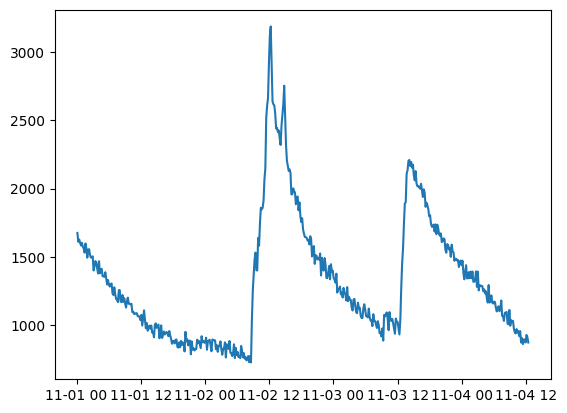

In [84]:
plt.plot(df_series["datetime"][:500], df_series["co2"][:500])

In [85]:
max_id = np.argmax(df_series["co2"][:500]) 
df_series["datetime"][max_id]

Timestamp('2023-11-01 21:32:07')

In [83]:
#plotting af 3 day window

n = 3*24*60*60/600
n

432.0

In [81]:
df_series["co2"].describe()

count    14292.000000
mean       829.529177
std        517.716728
min        341.000000
25%        517.000000
50%        621.000000
75%        897.000000
max       5651.000000
Name: co2, dtype: float64